In [1]:
import pickle

import numpy as np
import matplotlib.pyplot as plt
import json
import sqlite3

In [2]:
file = "results/bf_results_len11.pkl"

def stream_results(filename):
    with open(filename, 'rb') as f:
        while True:
            try:
                # Reads the next object from the stream
                yield pickle.load(f)
            except EOFError:
                # We reached the end of the file
                break

In [11]:
max_runtime = 100_001
num_runtimes = np.zeros(max_runtime, dtype=int)
num_runtimes_weighted = np.zeros(max_runtime, dtype=float)

# go through all rows in the table
counter = 0
for result in stream_results(file):
    # 'result' is the dictionary for a single simulation
    counter += 1
    steps = result["steps"]
    length = len(result["program"])
    weight = 7 ** (-length)
    num_runtimes[steps] += 1
    num_runtimes_weighted[steps] += weight

    if counter % 1_000_000 == 0:
        print(f"Processed {counter} results, most common runtime: {np.argmax(num_runtimes[:1000])} with {max(num_runtimes[:1000])} programs")

Processed 1000000 results, most common runtime: 9 with 322294 programs
Processed 2000000 results, most common runtime: 9 with 733867 programs
Processed 3000000 results, most common runtime: 9 with 925725 programs
Processed 4000000 results, most common runtime: 9 with 996470 programs
Processed 5000000 results, most common runtime: 10 with 1187862 programs
Processed 6000000 results, most common runtime: 10 with 1693327 programs
Processed 7000000 results, most common runtime: 10 with 2309476 programs
Processed 8000000 results, most common runtime: 10 with 2942297 programs
Processed 9000000 results, most common runtime: 10 with 3391016 programs
Processed 10000000 results, most common runtime: 10 with 3488850 programs
Processed 11000000 results, most common runtime: 10 with 3712292 programs
Processed 12000000 results, most common runtime: 10 with 3712567 programs
Processed 13000000 results, most common runtime: 10 with 3712803 programs
Processed 14000000 results, most common runtime: 10 wit

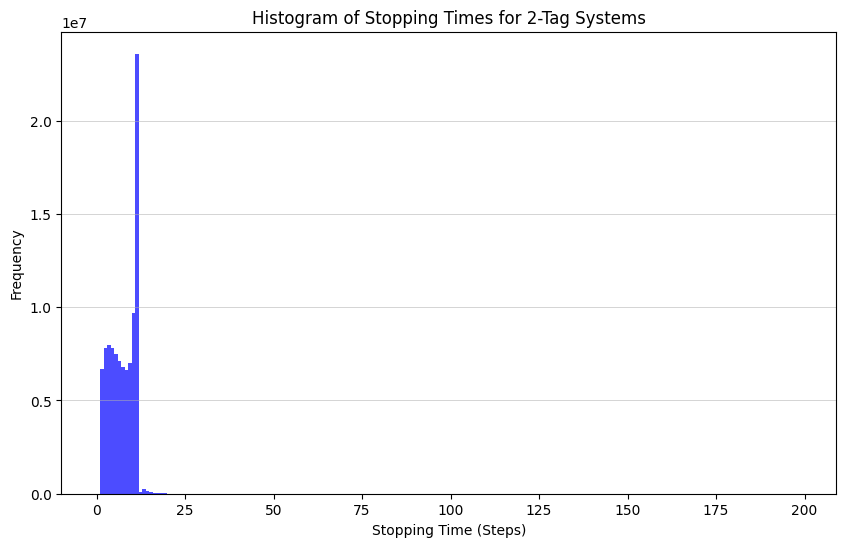

In [12]:
# coarse-grained histogram
num_bins = 200
max_plotted_runtime = 200
halting_num_runtimes = num_runtimes[:max_plotted_runtime]
hist, bin_edges = np.histogram(np.arange(max_plotted_runtime), bins=num_bins, weights=halting_num_runtimes)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.bar(bin_centers, hist, width=bin_edges[1] - bin_edges[0], alpha=0.7, color='blue')
plt.title('Histogram of Stopping Times for 2-Tag Systems')
plt.xlabel('Stopping Time (Steps)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [13]:
print(f"Percentage of programs that halt: {np.sum(num_runtimes[:-1]) * 100 / np.sum(num_runtimes)}%")

Percentage of programs that halt: 100.0%


In [14]:
# list runtimes from most common to least common
sorted_indices = np.argsort(num_runtimes)[::-1]  # Sort in descending order
sorted_runtimes = num_runtimes[sorted_indices]

In [15]:
# print 100 most common runtimes
print("Most common runtimes (steps):")
for i in range(100):
    runtime = sorted_indices[i]
    frequency = sorted_runtimes[i]
    print(f"Runtime: {runtime}, Frequency: {frequency}")

Most common runtimes (steps):
Runtime: 11, Frequency: 23591631
Runtime: 10, Frequency: 9707831
Runtime: 3, Frequency: 7995659
Runtime: 2, Frequency: 7812157
Runtime: 4, Frequency: 7795458
Runtime: 5, Frequency: 7474766
Runtime: 6, Frequency: 7120060
Runtime: 9, Frequency: 7019722
Runtime: 7, Frequency: 6808485
Runtime: 1, Frequency: 6709202
Runtime: 8, Frequency: 6649539
Runtime: 519, Frequency: 563422
Runtime: 13, Frequency: 267714
Runtime: 517, Frequency: 253340
Runtime: 773, Frequency: 200070
Runtime: 518, Frequency: 184842
Runtime: 1027, Frequency: 161148
Runtime: 515, Frequency: 135572
Runtime: 14, Frequency: 127810
Runtime: 516, Frequency: 117010
Runtime: 15, Frequency: 111956
Runtime: 1281, Frequency: 103568
Runtime: 1535, Frequency: 73526
Runtime: 12, Frequency: 72246
Runtime: 770, Frequency: 72216
Runtime: 514, Frequency: 65042
Runtime: 772, Frequency: 61826
Runtime: 1789, Frequency: 49188
Runtime: 1026, Frequency: 45300
Runtime: 17, Frequency: 44330
Runtime: 1023, Frequency: 

In [16]:
# print all runtimes that occur exactly once or twice
print("Runtimes that occur exactly once or twice:")
num_runtimes_at_most_twice = 0
for i in range(max_runtime):
    if num_runtimes[i] <= 2 and num_runtimes[i] > 0:
        print(f"Runtime: {i}, Frequency: {num_runtimes[i]}")
        num_runtimes_at_most_twice += 1

print(f"Total number of runtimes that occur at most twice: {num_runtimes_at_most_twice}")

Runtimes that occur exactly once or twice:
Runtime: 304, Frequency: 2
Runtime: 308, Frequency: 2
Runtime: 317, Frequency: 2
Runtime: 320, Frequency: 2
Runtime: 341, Frequency: 2
Runtime: 354, Frequency: 2
Runtime: 382, Frequency: 2
Runtime: 505, Frequency: 2
Runtime: 506, Frequency: 2
Runtime: 586, Frequency: 2
Runtime: 615, Frequency: 2
Runtime: 622, Frequency: 2
Runtime: 883, Frequency: 2
Runtime: 922, Frequency: 2
Runtime: 927, Frequency: 2
Runtime: 1171, Frequency: 2
Runtime: 1229, Frequency: 2
Runtime: 1232, Frequency: 2
Runtime: 1368, Frequency: 2
Runtime: 1408, Frequency: 2
Runtime: 1415, Frequency: 2
Runtime: 1466, Frequency: 2
Runtime: 1888, Frequency: 2
Runtime: 2554, Frequency: 2
Runtime: 2789, Frequency: 2
Runtime: 2812, Frequency: 2
Runtime: 3055, Frequency: 2
Runtime: 3061, Frequency: 2
Runtime: 3063, Frequency: 2
Total number of runtimes that occur at most twice: 29


In [17]:
# write runtimes ordered by frequency to a csv file
import csv
with open('tag_runtimes_frequency.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Runtime (Steps)', 'Frequency'])
    for i in range(len(sorted_indices)):
        runtime = sorted_indices[i]
        frequency = sorted_runtimes[i]
        if frequency == 0:
            break
        writer.writerow([runtime, frequency])

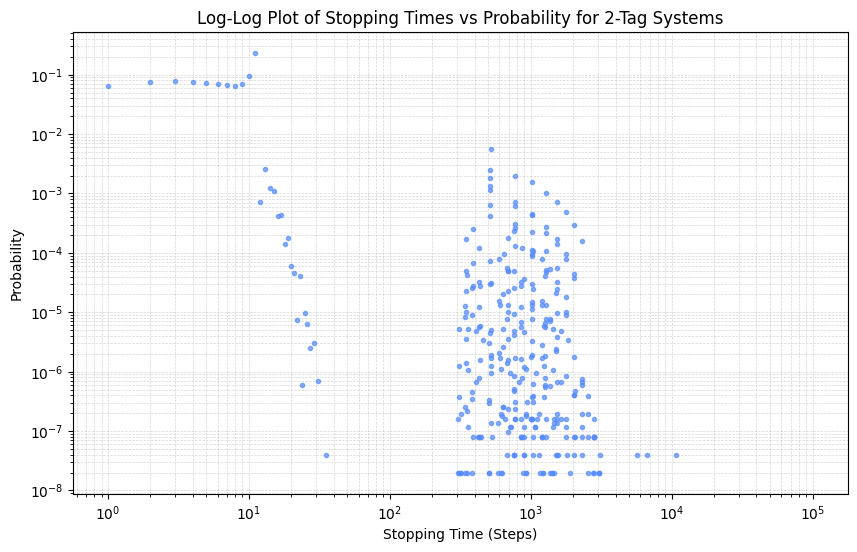

In [18]:
# log-log plot of runtimes against probability
total_programs = np.sum(num_runtimes)
probabilities = num_runtimes / total_programs

# Create a log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(np.arange(max_runtime), probabilities, marker='o', linestyle='None', markersize=3, alpha=0.7)
plt.title('Log-Log Plot of Stopping Times vs Probability for 2-Tag Systems')
plt.xlabel('Stopping Time (Steps)')
plt.ylabel('Probability')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

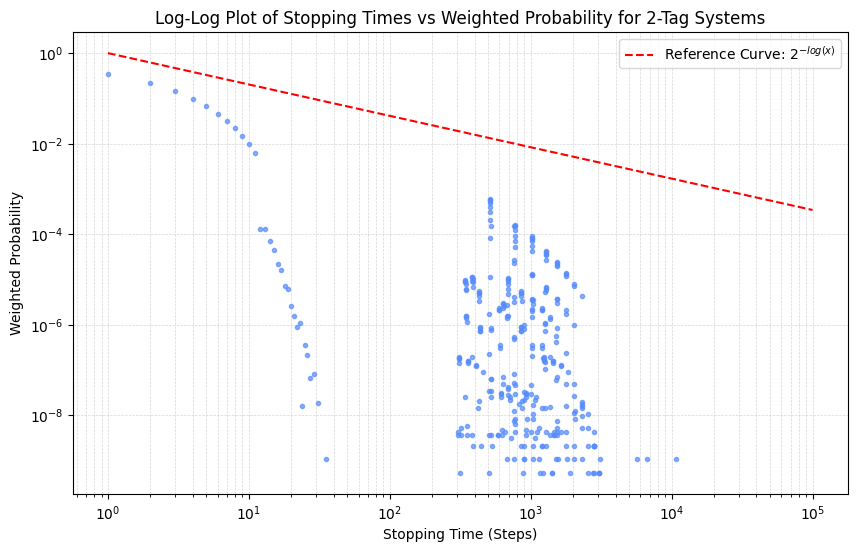

In [21]:
# same plot, but weighted by program length
total_weighted_programs = np.sum(num_runtimes_weighted)
weighted_probabilities = num_runtimes_weighted / total_weighted_programs

# Create a log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(np.arange(max_runtime), weighted_probabilities, marker='o', linestyle='None', markersize=3, alpha=0.7)

# add a curve 2**(- log x) as reference
reference_curve = 2 ** (-np.log(np.arange(1, max_runtime)))
plt.loglog(np.arange(1, max_runtime), reference_curve, color='red', linestyle='--', label='Reference Curve: $2^{-log(x)}$')
plt.legend()

plt.title('Log-Log Plot of Stopping Times vs Weighted Probability for 2-Tag Systems')
plt.xlabel('Stopping Time (Steps)')
plt.ylabel('Weighted Probability')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()